In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
import numpy as np

/home/rtis-lab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json
from composite_pruning import evaluate_composite_sweep

In [3]:
from dotenv import load_dotenv
from huggingface_hub import login
import os

In [4]:
import matplotlib.pyplot as plt

In [5]:
load_dotenv()
login(token=os.getenv("HF_TOKEN"))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [6]:
from eval_functions import evaluate_gsm8k, score_choice, evaluate_arc, evaluate_perplexity
from wanda_pruning import evaluate_wanda_sweep
from layerwise_perturbation import layerwise_reasoning_sensitivity

In [7]:
MODEL_NAME = "meta-llama/Llama-3.2-3B"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [9]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,   
    device_map="auto"            
)

Loading weights: 100%|██████████| 254/254 [00:01<00:00, 149.73it/s]


In [10]:
model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (

In [11]:
results = {}
results['gsm8k'] = evaluate_gsm8k(model, tokenizer, num_samples=200)
results['arc_challenge'] = evaluate_arc(model, tokenizer, num_samples=200)
results['perplexity'] = evaluate_perplexity(model, tokenizer)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for op

GSM8K Accuracy: 0.220 (44/200)
ARC-Challenge Accuracy: 0.435 (87/200)
Perplexity (WikiText-2): 8.63


In [11]:
for k, v in results.items():
    print(f"{k}: {v}")

gsm8k: 0.23
arc_challenge: 0.435
perplexity: 8.62353908467117


In [12]:
sparsities = [0.2, 0.4, 0.6]
wanda_results = evaluate_wanda_sweep(
    AutoModelForCausalLM,
    MODEL_NAME,
    tokenizer,
    sparsities,
    evaluate_gsm8k,
    evaluate_arc,
    evaluate_perplexity,
)
for sp, metrics in wanda_results.items():
    print(sp, metrics)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights: 100%|██████████| 254/254 [00:00<00:00, 270.24it/s]
Token indices sequence length is longer than the specified maximum sequence length for this model (139222 > 131072). Running this sequence through the model will result in indexing errors
wanda calib: 100%|██████████| 32/32 [00:00<00:00, 32.31it/s]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to 

GSM8K Accuracy: 0.220 (44/200)
ARC-Challenge Accuracy: 0.425 (85/200)
Perplexity (WikiText-2): 8.83


wanda calib: 100%|██████████| 32/32 [00:00<00:00, 32.46it/s]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end ge

GSM8K Accuracy: 0.155 (31/200)
ARC-Challenge Accuracy: 0.365 (73/200)
Perplexity (WikiText-2): 11.43


wanda calib: 100%|██████████| 32/32 [00:00<00:00, 32.44it/s]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end ge

GSM8K Accuracy: 0.050 (10/200)
ARC-Challenge Accuracy: 0.265 (53/200)
Perplexity (WikiText-2): 59.18
0.2 {'gsm8k': 0.22, 'arc_challenge': 0.425, 'perplexity': np.float64(8.832272678064067)}
0.4 {'gsm8k': 0.155, 'arc_challenge': 0.365, 'perplexity': np.float64(11.427121267789712)}
0.6 {'gsm8k': 0.05, 'arc_challenge': 0.265, 'perplexity': np.float64(59.181801643794095)}


In [13]:
layerwise_results = layerwise_reasoning_sensitivity(
    model,
    tokenizer,
    evaluate_gsm8k,
    num_samples=200,
    scale=0.5,
)
print("baseline", layerwise_results["baseline"])
for row in layerwise_results["per_layer"]:
    print(row)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

GSM8K Accuracy: 0.230 (46/200)


layer perturb:   0%|          | 0/28 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation

GSM8K Accuracy: 0.150 (30/200)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

...

GSM8K Accuracy: 0.190 (38/200)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

GSM8K Accuracy: 0.175 (35/200)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

GSM8K Accuracy: 0.230 (46/200)
baseline 0.23
{'layer': 0, 'accuracy': 0.15, 'drop': 0.08000000000000002, 'sensitivity': 0.08000000000000002}
{'layer': 1, 'accuracy': 0.125, 'drop': 0.10500000000000001, 'sensitivity': 0.10500000000000001}
{'layer': 2, 'accuracy': 0.13, 'drop': 0.1, 'sensitivity': 0.1}
{'layer': 3, 'accuracy': 0.11, 'drop': 0.12000000000000001, 'sensitivity': 0.12000000000000001}
{'layer': 4, 'accuracy': 0.135, 'drop': 0.095, 'sensitivity': 0.095}
{'layer': 5, 'accuracy': 0.13, 'drop': 0.1, 'sensitivity': 0.1}
{'layer': 6, 'accuracy': 0.105, 'drop': 0.125, 'sensitivity': 0.125}
{'layer': 7, 'accuracy': 0.09, 'drop': 0.14, 'sensitivity': 0.14}
{'layer': 8, 'accuracy': 0.1, 'drop': 0.13, 'sensitivity': 0.13}
{'layer': 9, 'accuracy': 0.095, 'drop': 0.135, 'sensitivity': 0.135}
{'layer': 10, 'accuracy': 0.1, 'drop': 0.13, 'sensitivity': 0.13}
{'layer': 11, 'accuracy': 0.105, 'drop': 0.125, 'sensitivity': 0.125}
{'layer': 12, 'accuracy': 0.12, 'drop': 0.11000000000000001, 'se

In [14]:
layerwise_results

{'baseline': 0.23,
 'per_layer': [{'layer': 0,
   'accuracy': 0.15,
   'drop': 0.08000000000000002,
   'sensitivity': 0.08000000000000002},
  {'layer': 1,
   'accuracy': 0.125,
   'drop': 0.10500000000000001,
   'sensitivity': 0.10500000000000001},
  {'layer': 2, 'accuracy': 0.13, 'drop': 0.1, 'sensitivity': 0.1},
  {'layer': 3,
   'accuracy': 0.11,
   'drop': 0.12000000000000001,
   'sensitivity': 0.12000000000000001},
  {'layer': 4, 'accuracy': 0.135, 'drop': 0.095, 'sensitivity': 0.095},
  {'layer': 5, 'accuracy': 0.13, 'drop': 0.1, 'sensitivity': 0.1},
  {'layer': 6, 'accuracy': 0.105, 'drop': 0.125, 'sensitivity': 0.125},
  {'layer': 7, 'accuracy': 0.09, 'drop': 0.14, 'sensitivity': 0.14},
  {'layer': 8, 'accuracy': 0.1, 'drop': 0.13, 'sensitivity': 0.13},
  {'layer': 9, 'accuracy': 0.095, 'drop': 0.135, 'sensitivity': 0.135},
  {'layer': 10, 'accuracy': 0.1, 'drop': 0.13, 'sensitivity': 0.13},
  {'layer': 11, 'accuracy': 0.105, 'drop': 0.125, 'sensitivity': 0.125},
  {'layer': 12

In [15]:
for i in layerwise_results['per_layer']:
    print(i)

{'layer': 0, 'accuracy': 0.15, 'drop': 0.08000000000000002, 'sensitivity': 0.08000000000000002}
{'layer': 1, 'accuracy': 0.125, 'drop': 0.10500000000000001, 'sensitivity': 0.10500000000000001}
{'layer': 2, 'accuracy': 0.13, 'drop': 0.1, 'sensitivity': 0.1}
{'layer': 3, 'accuracy': 0.11, 'drop': 0.12000000000000001, 'sensitivity': 0.12000000000000001}
{'layer': 4, 'accuracy': 0.135, 'drop': 0.095, 'sensitivity': 0.095}
{'layer': 5, 'accuracy': 0.13, 'drop': 0.1, 'sensitivity': 0.1}
{'layer': 6, 'accuracy': 0.105, 'drop': 0.125, 'sensitivity': 0.125}
{'layer': 7, 'accuracy': 0.09, 'drop': 0.14, 'sensitivity': 0.14}
{'layer': 8, 'accuracy': 0.1, 'drop': 0.13, 'sensitivity': 0.13}
{'layer': 9, 'accuracy': 0.095, 'drop': 0.135, 'sensitivity': 0.135}
{'layer': 10, 'accuracy': 0.1, 'drop': 0.13, 'sensitivity': 0.13}
{'layer': 11, 'accuracy': 0.105, 'drop': 0.125, 'sensitivity': 0.125}
{'layer': 12, 'accuracy': 0.12, 'drop': 0.11000000000000001, 'sensitivity': 0.11000000000000001}
{'layer': 13

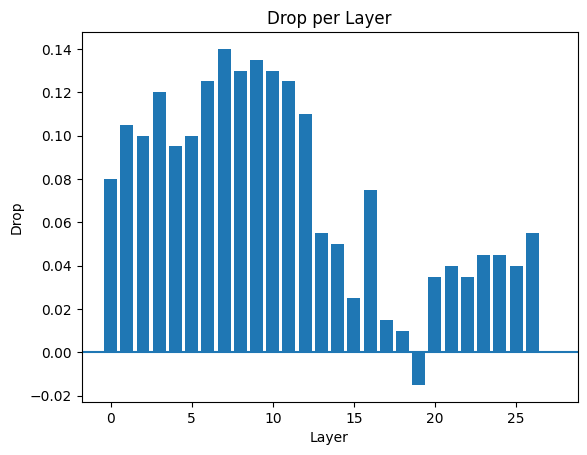

In [11]:
layers = [entry['layer'] for entry in layerwise_results['per_layer']]
drops = [entry['drop'] for entry in layerwise_results['per_layer']]

plt.figure()
plt.bar(layers, drops)

# 0 reference line
plt.axhline(0)

plt.xlabel("Layer")
plt.ylabel("Drop")
plt.title("Drop per Layer")
plt.show()

In [9]:
layerwise_results = {
    'baseline': 0.23,
    'per_layer': [
        {'layer': 0, 'accuracy': 0.15, 'drop': 0.08000000000000002, 'sensitivity': 0.08000000000000002},
        {'layer': 1, 'accuracy': 0.125, 'drop': 0.10500000000000001, 'sensitivity': 0.10500000000000001},
        {'layer': 2, 'accuracy': 0.13, 'drop': 0.1, 'sensitivity': 0.1},
        {'layer': 3, 'accuracy': 0.11, 'drop': 0.12000000000000001, 'sensitivity': 0.12000000000000001},
        {'layer': 4, 'accuracy': 0.135, 'drop': 0.095, 'sensitivity': 0.095},
        {'layer': 5, 'accuracy': 0.13, 'drop': 0.1, 'sensitivity': 0.1},
        {'layer': 6, 'accuracy': 0.105, 'drop': 0.125, 'sensitivity': 0.125},
        {'layer': 7, 'accuracy': 0.09, 'drop': 0.14, 'sensitivity': 0.14},
        {'layer': 8, 'accuracy': 0.1, 'drop': 0.13, 'sensitivity': 0.13},
        {'layer': 9, 'accuracy': 0.095, 'drop': 0.135, 'sensitivity': 0.135},
        {'layer': 10, 'accuracy': 0.1, 'drop': 0.13, 'sensitivity': 0.13},
        {'layer': 11, 'accuracy': 0.105, 'drop': 0.125, 'sensitivity': 0.125},
        {'layer': 12, 'accuracy': 0.12, 'drop': 0.11000000000000001, 'sensitivity': 0.11000000000000001},
        {'layer': 13, 'accuracy': 0.175, 'drop': 0.05500000000000002, 'sensitivity': 0.05500000000000002},
        {'layer': 14, 'accuracy': 0.18, 'drop': 0.05000000000000002, 'sensitivity': 0.05000000000000002},
        {'layer': 15, 'accuracy': 0.205, 'drop': 0.025000000000000022, 'sensitivity': 0.025000000000000022},
        {'layer': 16, 'accuracy': 0.155, 'drop': 0.07500000000000001, 'sensitivity': 0.07500000000000001},
        {'layer': 17, 'accuracy': 0.215, 'drop': 0.015000000000000013, 'sensitivity': 0.015000000000000013},
        {'layer': 18, 'accuracy': 0.22, 'drop': 0.010000000000000009, 'sensitivity': 0.010000000000000009},
        {'layer': 19, 'accuracy': 0.245, 'drop': -0.014999999999999986, 'sensitivity': -0.014999999999999986},
        {'layer': 20, 'accuracy': 0.195, 'drop': 0.035, 'sensitivity': 0.035},
        {'layer': 21, 'accuracy': 0.19, 'drop': 0.04000000000000001, 'sensitivity': 0.04000000000000001},
        {'layer': 22, 'accuracy': 0.195, 'drop': 0.035, 'sensitivity': 0.035},
        {'layer': 23, 'accuracy': 0.185, 'drop': 0.04500000000000001, 'sensitivity': 0.04500000000000001},
        {'layer': 24, 'accuracy': 0.185, 'drop': 0.04500000000000001, 'sensitivity': 0.04500000000000001},
        {'layer': 25, 'accuracy': 0.19, 'drop': 0.04000000000000001, 'sensitivity': 0.04000000000000001},
        {'layer': 26, 'accuracy': 0.175, 'drop': 0.05500000000000002, 'sensitivity': 0.05500000000000002},
        {'layer': 27, 'accuracy': 0.23, 'drop': 0.0, 'sensitivity': 0.0}
    ]
}

In [10]:
sparsities = [0.2, 0.4, 0.6]

# alpha=1.0 is pure Wanda 
# alpha=0.5 is equal weighting
# alpha=0.0 is pure sensitivity
alphas = [0.3, 0.5, 0.7]

In [11]:
composite_results = evaluate_composite_sweep(
    model_cls=AutoModelForCausalLM,
    model_name=MODEL_NAME,
    tokenizer=tokenizer,
    sensitivity_results=layerwise_results,
    sparsities=sparsities,
    alphas=alphas,
    eval_gsm8k=evaluate_gsm8k,
    eval_arc=evaluate_arc,
    eval_ppl=evaluate_perplexity,
)

`torch_dtype` is deprecated! Use `dtype` instead!



Sparsity = 0.2


Loading weights: 100%|██████████| 254/254 [00:01<00:00, 244.22it/s]
Token indices sequence length is longer than the specified maximum sequence length for this model (139222 > 131072). Running this sequence through the model will result in indexing errors
collecting activations: 100%|██████████| 32/32 [00:01<00:00, 26.61it/s]



-- Alpha = 0.3 --


Loading weights: 100%|██████████| 254/254 [00:01<00:00, 252.84it/s]


...

GSM8K Accuracy: 0.055 (11/200)
ARC-Challenge Accuracy: 0.260 (52/200)
Perplexity (WikiText-2): 59.08

-- Alpha = 0.7 --


Loading weights: 100%|██████████| 254/254 [00:01<00:00, 251.31it/s]


Composite pruning applied at sparsity=0.6


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

GSM8K Accuracy: 0.050 (10/200)
ARC-Challenge Accuracy: 0.265 (53/200)
Perplexity (WikiText-2): 59.14


In [12]:
composite_results

{0.2: {0.3: {'gsm8k': 0.225,
   'arc_challenge': 0.42,
   'perplexity': np.float64(8.834098444575103)},
  0.5: {'gsm8k': 0.22,
   'arc_challenge': 0.42,
   'perplexity': np.float64(8.832699371618096)},
  0.7: {'gsm8k': 0.225,
   'arc_challenge': 0.42,
   'perplexity': np.float64(8.831084441207686)}},
 0.4: {0.3: {'gsm8k': 0.155,
   'arc_challenge': 0.365,
   'perplexity': np.float64(11.428022240902905)},
  0.5: {'gsm8k': 0.15,
   'arc_challenge': 0.365,
   'perplexity': np.float64(11.425992044030533)},
  0.7: {'gsm8k': 0.15,
   'arc_challenge': 0.365,
   'perplexity': np.float64(11.42404630190305)}},
 0.6: {0.3: {'gsm8k': 0.05,
   'arc_challenge': 0.26,
   'perplexity': np.float64(59.14173564061327)},
  0.5: {'gsm8k': 0.055,
   'arc_challenge': 0.26,
   'perplexity': np.float64(59.08263831304832)},
  0.7: {'gsm8k': 0.05,
   'arc_challenge': 0.265,
   'perplexity': np.float64(59.14124212557218)}}}

In [ ]:
with open("composite_results.json", "w") as f:
    json.dump(composite_results, f, indent=4, default=float)

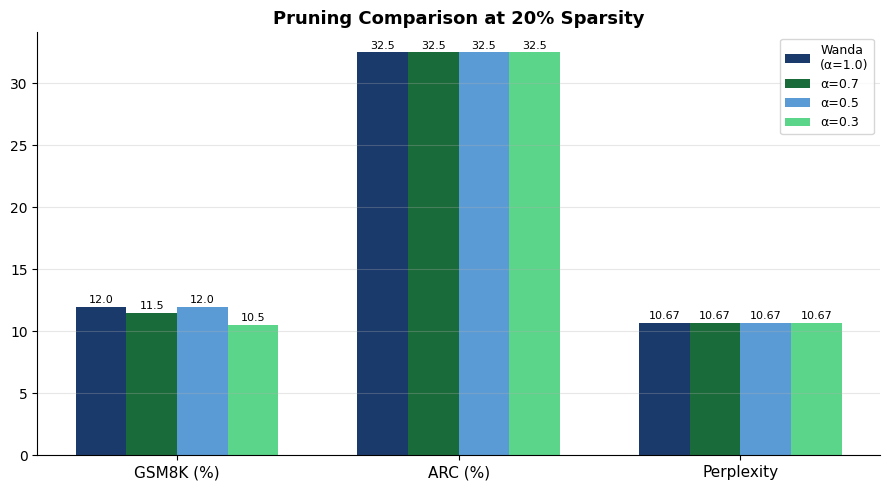

In [ ]:
methods = ['Wanda\n(α=1.0)', 'α=0.7', 'α=0.5', 'α=0.3']
metrics = ['GSM8K (%)', 'ARC (%)', 'Perplexity']
data    = [
    [12.0, 32.5, 10.67],
    [11.5, 32.5, 10.67],
    [12.0, 32.5, 10.67],
    [10.5, 32.5, 10.67],
]

colors = ['#1a3a6b', '#1a6b3a', '#5b9bd5', '#5bd58a']
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(9, 5))

for i, (method, vals, color) in enumerate(zip(methods, data, colors)):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=method, color=color)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.15,
                str(val), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_title('Pruning Comparison at 20% Sparsity', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
llama3b_wanda = {
    0.2: {'gsm8k': 22.0, 'arc': 42.5, 'ppl':  8.832},
    0.4: {'gsm8k': 15.5, 'arc': 36.5, 'ppl': 11.427},
    0.6: {'gsm8k':  5.0, 'arc': 26.5, 'ppl': 59.182},
}

llama3b_composite = {
    0.2: {0.7: {'gsm8k': 22.5, 'arc': 42.0, 'ppl':  8.831},
          0.5: {'gsm8k': 22.0, 'arc': 42.0, 'ppl':  8.833},
          0.3: {'gsm8k': 22.5, 'arc': 42.0, 'ppl':  8.834}},
    0.4: {0.7: {'gsm8k': 15.0, 'arc': 36.5, 'ppl': 11.424},
          0.5: {'gsm8k': 15.0, 'arc': 36.5, 'ppl': 11.426},
          0.3: {'gsm8k': 15.5, 'arc': 36.5, 'ppl': 11.428}},
    0.6: {0.7: {'gsm8k':  5.0, 'arc': 26.5, 'ppl': 59.141},
          0.5: {'gsm8k':  5.5, 'arc': 26.0, 'ppl': 59.083},
          0.3: {'gsm8k':  5.0, 'arc': 26.0, 'ppl': 59.142}},
}

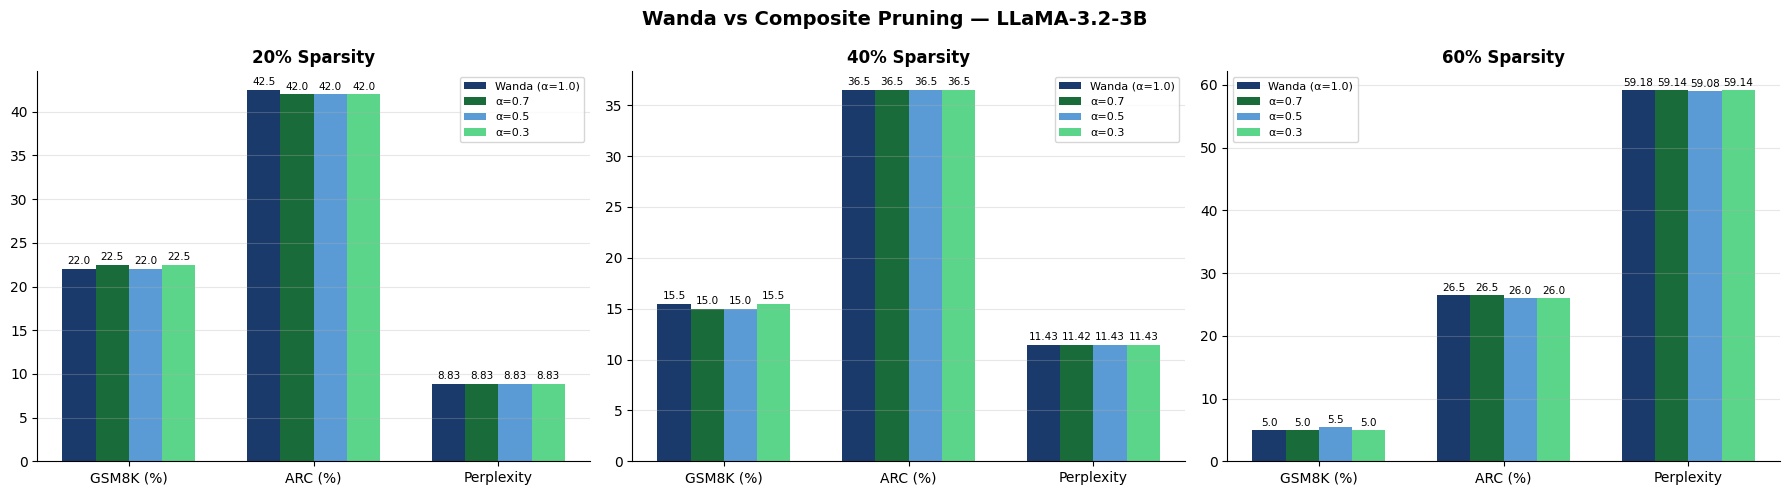

: 

In [ ]:
sparsities    = [0.2, 0.4, 0.6]
alphas        = [0.7, 0.5, 0.3]
metrics       = ['gsm8k', 'arc', 'ppl']
metric_labels = ['GSM8K (%)', 'ARC (%)', 'Perplexity']
method_labels = ['Wanda (α=1.0)', 'α=0.7', 'α=0.5', 'α=0.3']
colors        = ['#1a3a6b', '#1a6b3a', '#5b9bd5', '#5bd58a']
width         = 0.18
x             = np.arange(len(metrics))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Wanda vs Composite Pruning — LLaMA-3.2-3B', fontsize=14, fontweight='bold')

for ax, sp, sp_label in zip(axes, sparsities, ['20% Sparsity', '40% Sparsity', '60% Sparsity']):
    # Collect values: wanda first, then alphas
    all_vals = [[llama3b_wanda[sp][m] for m in metrics]]
    for a in alphas:
        all_vals.append([llama3b_composite[sp][a][m] for m in metrics])

    for i, (vals, label, color) in enumerate(zip(all_vals, method_labels, colors)):
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, vals, width, label=label, color=color)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    str(round(val, 2)),
                    ha='center', va='bottom', fontsize=7.5)

    ax.set_title(sp_label, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()